# Installing Libraries

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Loading And Inspecting Data

In [18]:
df= pd.read_csv("dirty_cafe_sales.csv") #Loading the dataset
df.head() # Display first 5 rows

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [19]:
df.tail() # Display last 5 rows

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02
9999,TXN_6170729,Sandwich,3,4.0,12.0,Cash,In-store,2023-11-07


In [20]:
df.info() # Information like datatypes 

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    10000 non-null  str  
 1   Item              9667 non-null   str  
 2   Quantity          9862 non-null   str  
 3   Price Per Unit    9821 non-null   str  
 4   Total Spent       9827 non-null   str  
 5   Payment Method    7421 non-null   str  
 6   Location          6735 non-null   str  
 7   Transaction Date  9841 non-null   str  
dtypes: str(8)
memory usage: 625.1 KB


In [21]:
df.describe() # Summary Information

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9862,9821,9827,7421,6735,9841
unique,10000,10,7,8,19,5,4,367
top,TXN_1961373,Juice,5,3.0,6.0,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2013,2429,979,2291,3022,159


In [22]:
df.shape #Shows number of rows and columns

(10000, 8)

 # Handle Missing Values 

In [ ]:
df.columns #Name of columns

Index(['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent',
       'Payment Method', 'Location', 'Transaction Date'],
      dtype='str')

In [28]:
df.isna().sum() ### Finding nun values

Transaction ID         0
Item                 333
Quantity             479
Price Per Unit       533
Total Spent          502
Payment Method      2579
Location            3265
Transaction Date     460
dtype: int64

In [24]:
#Converting non-numerical values to numerical 
#2   Quantity          9862 non-null   str  
#3   Price Per Unit    9821 non-null   str  
#4   Total Spent       9827 non-null   str 

df["Quantity"] = pd.to_numeric(df["Quantity"], errors= "coerce")
df["Price Per Unit"] = pd.to_numeric(df["Price Per Unit"], errors= "coerce")
df["Total Spent"] = pd.to_numeric(df["Total Spent"], errors= "coerce")


In [25]:
#Convert date columns

df["Transaction Date"] = pd.to_datetime(df["Transaction Date"], errors= "coerce")


In [32]:
#Filling Numerical columns using median

num_cols = ['Quantity', 'Price Per Unit', 'Total Spent']
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [ ]:
#Filling Date  columns with forward fill

df["Transaction Date"] = df["Transaction Date"].ffill()

In [37]:
#Checking after filling numerical and date

df.isna().sum()

Transaction ID         0
Item                 333
Quantity               0
Price Per Unit         0
Total Spent            0
Payment Method      2579
Location            3265
Transaction Date       0
dtype: int64

In [38]:
# Filling categorical columns with "unknown"

cat_cols = ['Item', 'Payment Method', 'Location']
for col in cat_cols:
    df[col] = df[col].fillna("Unknown")


In [39]:
# Checking after filling categorical column

df.isna().sum()

Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64

# Removing Duplicate Values

In [43]:
#Identify Duplicates

duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


# Detecting and Displaying Outliers

In [55]:
#Detect Outlier

Q1 = df["Total Spent"].quantile(0.25)
Q3 = df["Total Spent"].quantile(0.75)
IQR = Q3 - Q1 

lower_bound = Q1 - 1.5 * IQR 
upper_bound = Q3 + 1.5 * IQR 

outliers = df[(df["Total Spent"] < lower_bound) | (df["Total Spent"] > upper_bound)]
print("Dectected outliers in column: Total Spent Unique Outliers value:")
print(outliers["Total Spent"].unique())


Dectected outliers in column: Total Spent Unique Outliers value:
[25.]


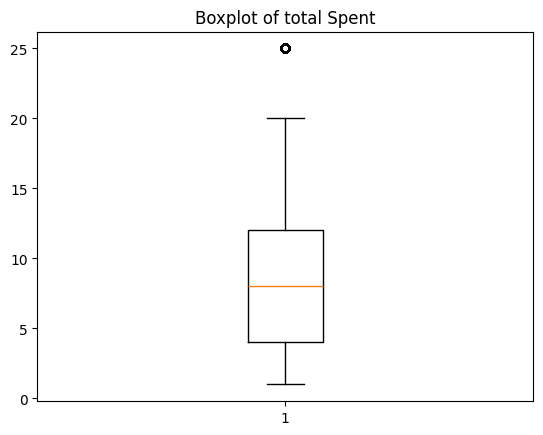

In [ ]:
#Boxplot 
plt.figure()
plt.boxplot(df["Total Spent"])
plt.title("Boxplot of total Spent")
plt.show()

# Removing Outlier

In [76]:
Q1 = df["Total Spent"].quantile(0.25)
Q3 = df["Total Spent"].quantile(0.75)
IQR = Q3 - Q1 

lower_bound = Q1 - 1.5 * IQR 
upper_bound = Q3 + 1.5 * IQR 

outliers = df[(df["Total Spent"] < lower_bound) | (df["Total Spent"] > upper_bound)]
mask = df[(df["Total Spent"] >= lower_bound) & (df["Total Spent"] <= upper_bound)]



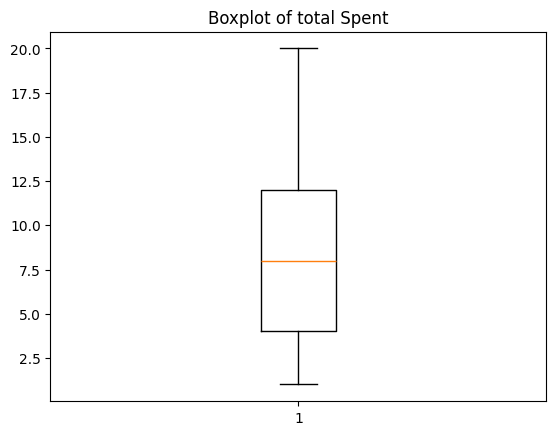

In [78]:
#Boxplot 
plt.figure()
plt.boxplot(mask["Total Spent"])
plt.title("Boxplot of total Spent")
plt.show()